# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 46 |  |
| :-------------|:-------------|
| Tim Omloo | 6567010 |
| Marjoksi Elyas| 6243355 |
| Steven Wijnands| 6580912|

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Marjoksi','Steven']

## Opdracht 1: Planning.

| Planning Groep: 46     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding | 11:00 - 11:15 |
| Kalibreren sensor | 11:15 - 11:45|
| Meetopsteling testen | 11:45 - 12:00 |
| Iteratie 1 begin | 12:00 - 12:30 |
| Pauze | 12:30 - 13:30 |
| Iteratie 1 | 13:30 - 15:30 |
| Iteratie 2 | 15:30 - 16:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="tudelftLogo.png" width="400">

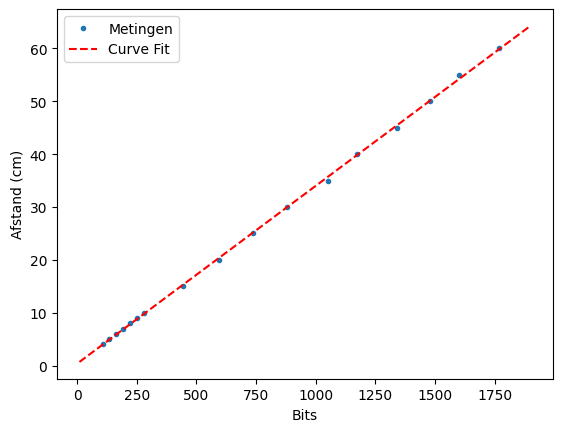

[0.03363692 0.34863315]


In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

bits = np.array([110,135,165,193,223,250,280,444,596,737,882,1050,1174,1340,1480,1600,1770]) #bits
afstanden = np.array([4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,55,60]) #cm

def fit(x,a,b):
    return a*x + b

ppov,pcov = curve_fit(fit,bits,afstanden)
x_test = np.linspace(10,1900,1000)

plt.figure()
plt.plot(bits,afstanden,'.',label='Metingen')
plt.plot(x_test,fit(x_test,*ppov),'r--',label='Curve Fit')
plt.xlabel('Bits')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()

print(ppov)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  48.1
1   0  30   0  20  48.8
2  40   0  30   0  46.8
3  30   0  20   0  46.1


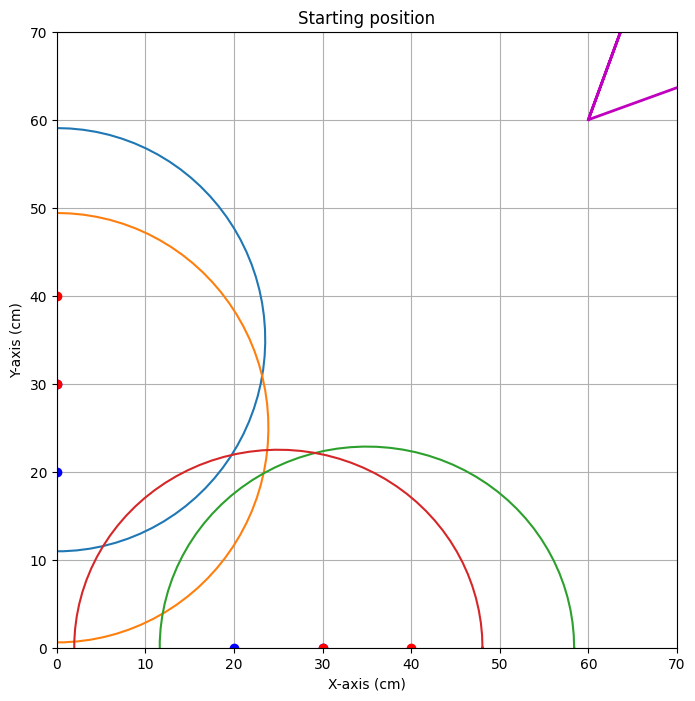


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=94.505


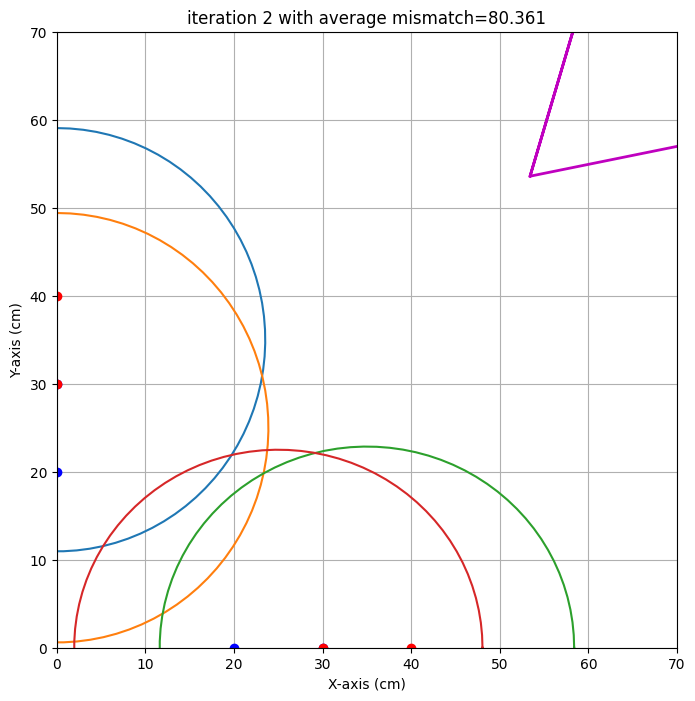

end iteration 2 with average mismatch=80.361


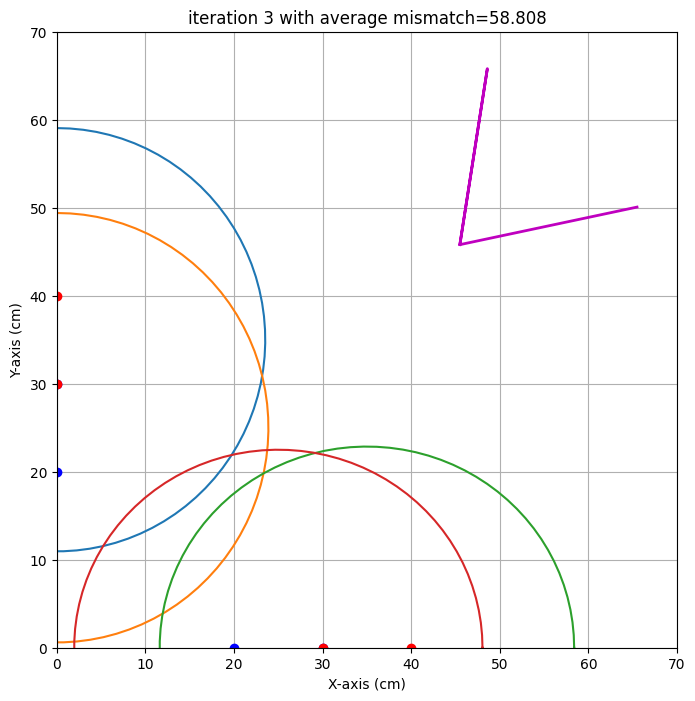

end iteration 3 with average mismatch=58.808


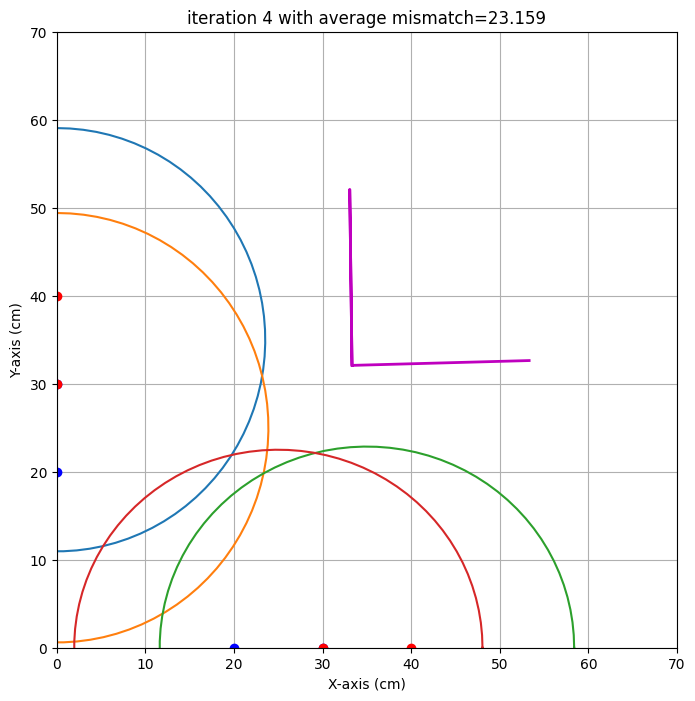

end iteration 4 with average mismatch=23.159


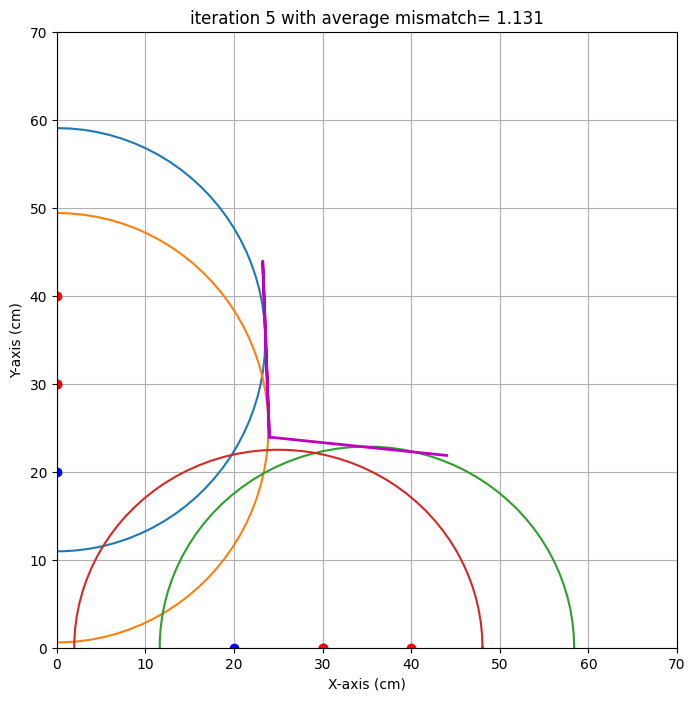

end iteration 5 with average mismatch= 1.131


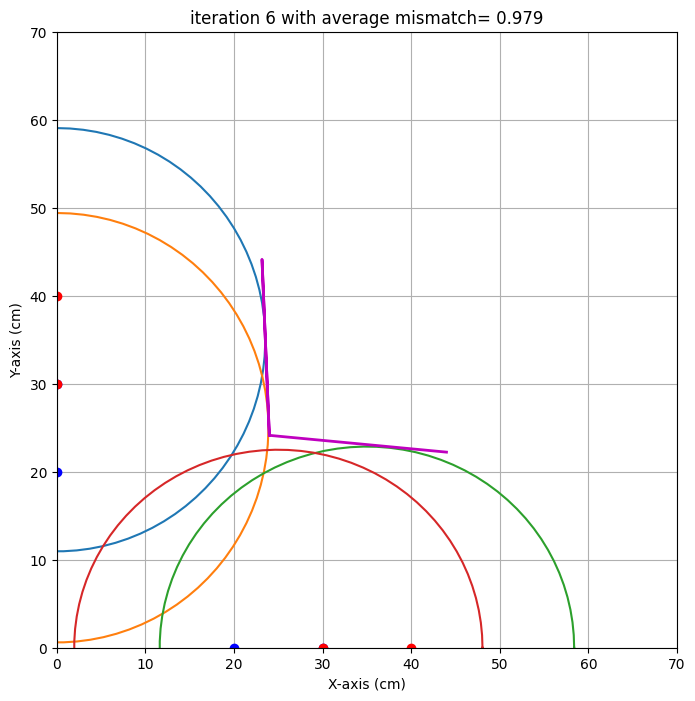

end iteration 6 with average mismatch= 0.979


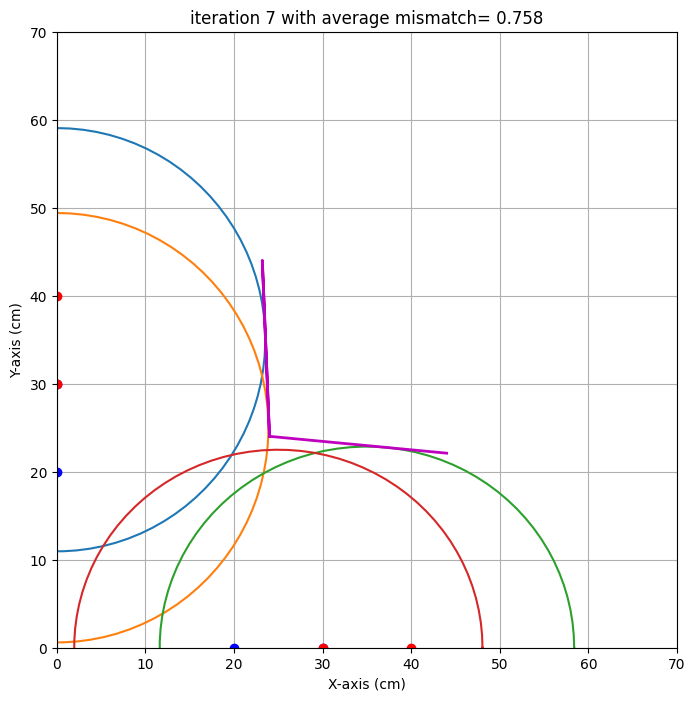

end iteration 7 with average mismatch= 0.758
end iteration 8 with average mismatch= 0.755


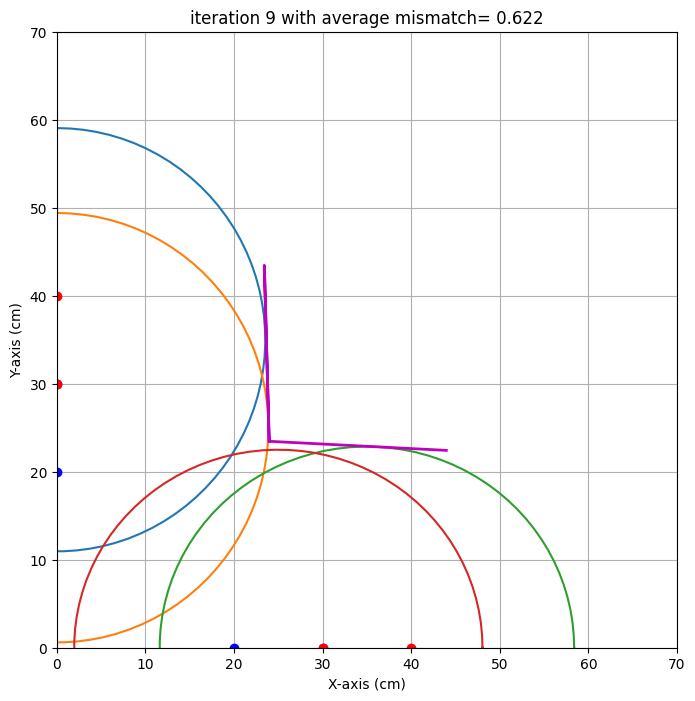

end iteration 9 with average mismatch= 0.622
end iteration 10 with average mismatch= 0.621
end iteration 11 with average mismatch= 0.585
end iteration 12 with average mismatch= 0.558
end iteration 13 with average mismatch= 0.558
end iteration 14 with average mismatch= 0.558
end iteration 15 with average mismatch= 0.558
end iteration 16 with average mismatch= 0.558


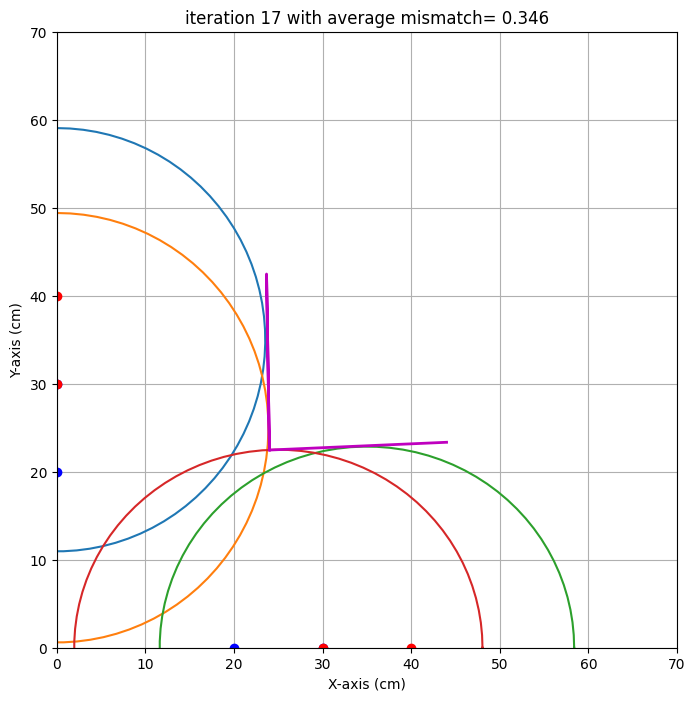

end iteration 17 with average mismatch= 0.346
end iteration 18 with average mismatch= 0.332
end iteration 19 with average mismatch= 0.328
end iteration 20 with average mismatch= 0.326
end iteration 21 with average mismatch= 0.326
end iteration 22 with average mismatch= 0.326
end iteration 23 with average mismatch= 0.326
end iteration 24 with average mismatch= 0.326
end iteration 25 with average mismatch= 0.326


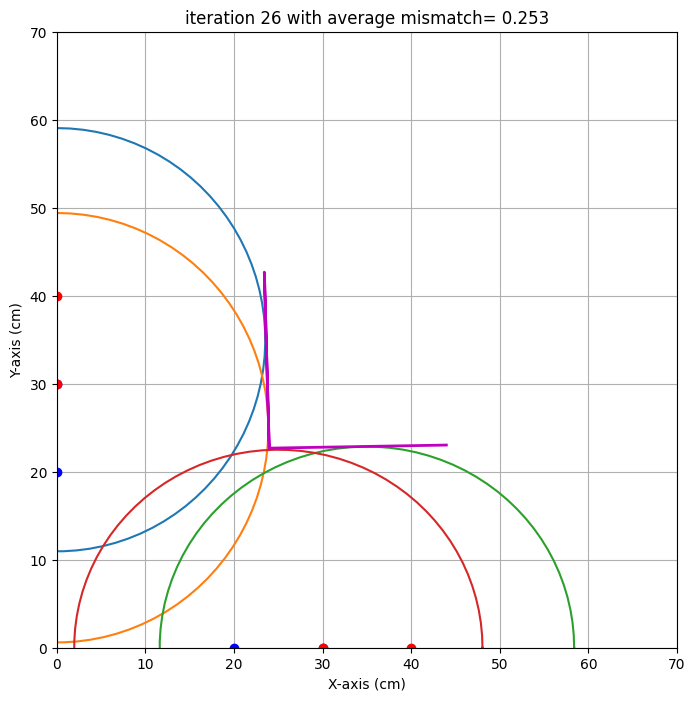

end iteration 26 with average mismatch= 0.253
end iteration 27 with average mismatch= 0.236
end iteration 28 with average mismatch= 0.236
end iteration 29 with average mismatch= 0.235
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.235
###############################################################################
end of iteration  30
Best alpha=   0.94 with uncertainty=   0.00
Best beta =  -1.58 with uncertainty=   0.00
Best x0   =  23.97 with uncertainty=   0.00
Best y0   =  22.68 with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


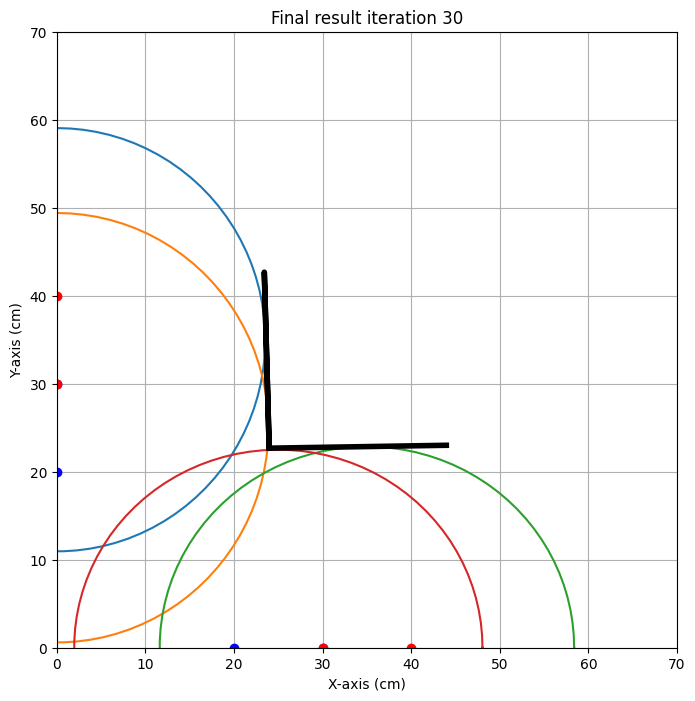

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

#origin is 2.5 centimeter naar achter geplaats, waardoor het karton niet op 20 maar 22.5 cm staat.

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,48.1],
    [0,30,0,20,48.8],
#   [0,10,0,20,170.0],
    [40,0,30,0,46.8],
    [30,0,20,0,46.1],
#    [10,0,20,0,165.0],
#   [10,0,0,10,180.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 24.0 cm met een standaardafwijking van 0.0 cm 
y0: 22.7 cm met een standaardafwijking van 0.0 cm 
alpha: 0.9 graden met een standaardafwijking van 0.0 graad 
beta: -1.6 graden met een standaardafwijking van 0.0 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Tim]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Tim.png" width="400">

#### algoritme [Marjoksi]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Marjoksi.png" width="400">

#### algoritme [Steven]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Steven.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [15]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 23.5,
           'alpha' : 14,
           'beta' : 10
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Steven' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[0,70,0,60,170] ongeldig
   [0,30,0,20,64.8],
   [0,40,0,30,62.3],
   [0,20,0,10,62.8],
   #[70,0,60,0,130] ongeldig 
   [30,0,20,0,53.0],
   [40,0,30,0,48.1]
    ]),
  'Marjoksi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,10,0,170] ongeldig
    [30,0,20,0,54.1],
    [40,0,30,0,53.3],
    [50,0,40,0,44.1],
    #[60,0,50,0,180] ongeldig
    [0,30,0,20,63.1],
    [0,40,0,30,59.7]
    #[0,40,0,50,170] ongeldig

    ]),
    'Tim' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


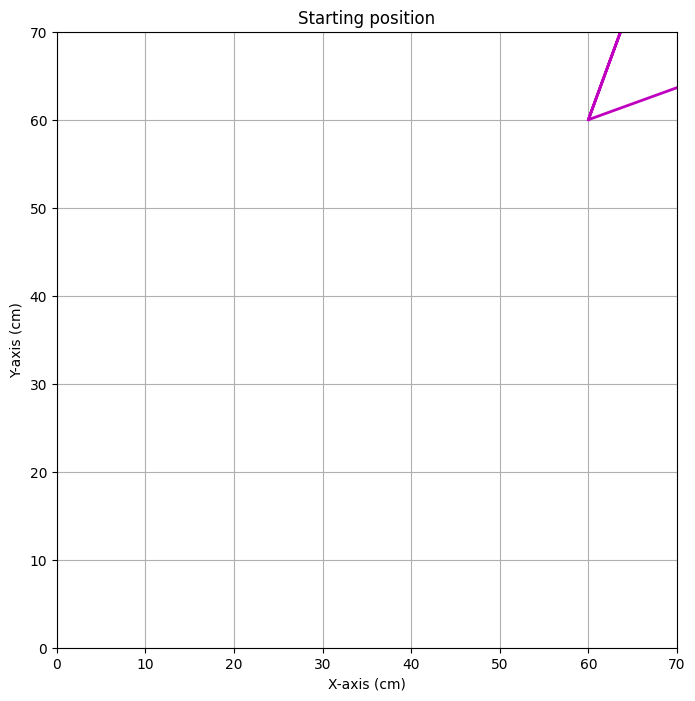


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with ave

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch=   nan
###############################################################################
end of iteration  30
Best alpha=    nan with uncertainty=   0.00
Best beta =    nan with uncertainty=   0.00
Best x0   =    nan with uncertainty=   0.00
Best y0   =    nan with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


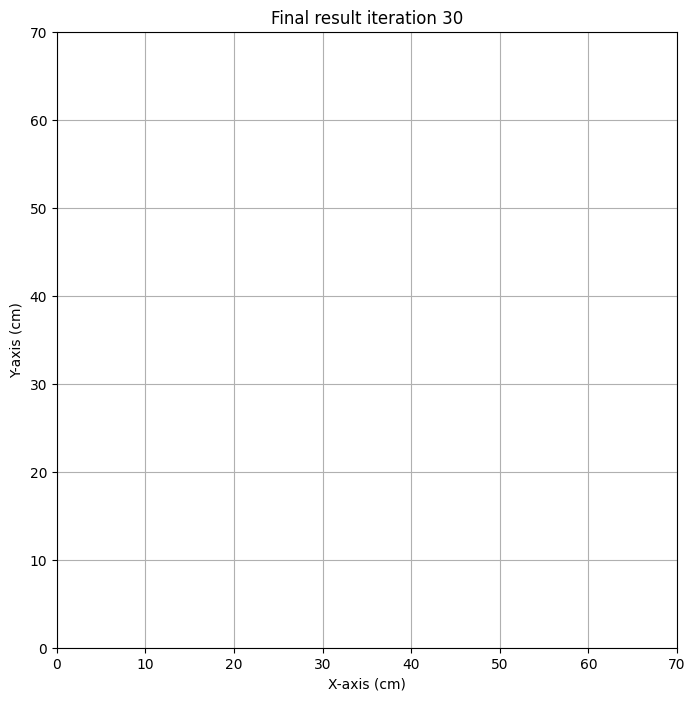

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}
Marjoksi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  20   0  54.1
1  40   0  30   0  53.3
2  50   0  40   0  44.1
3   0  30   0  20  63.1
4   0  40   0  30  59.7


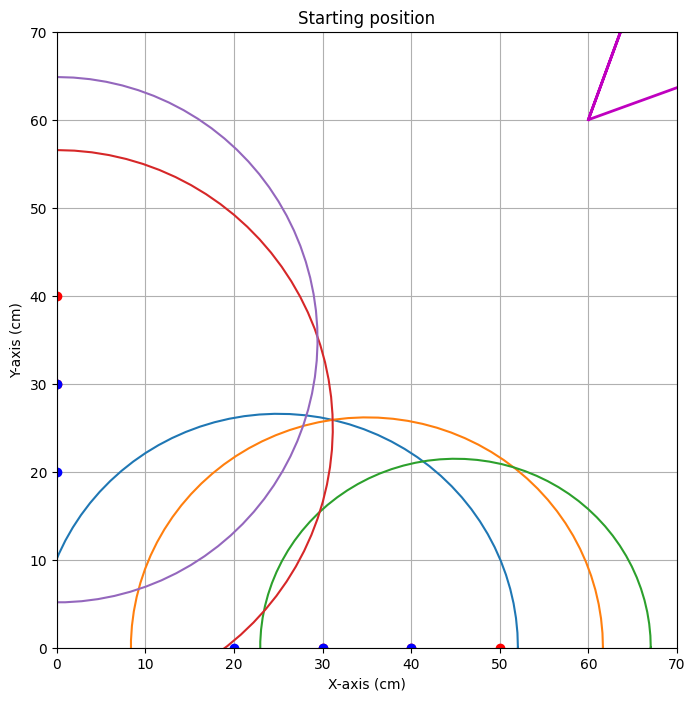


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.332


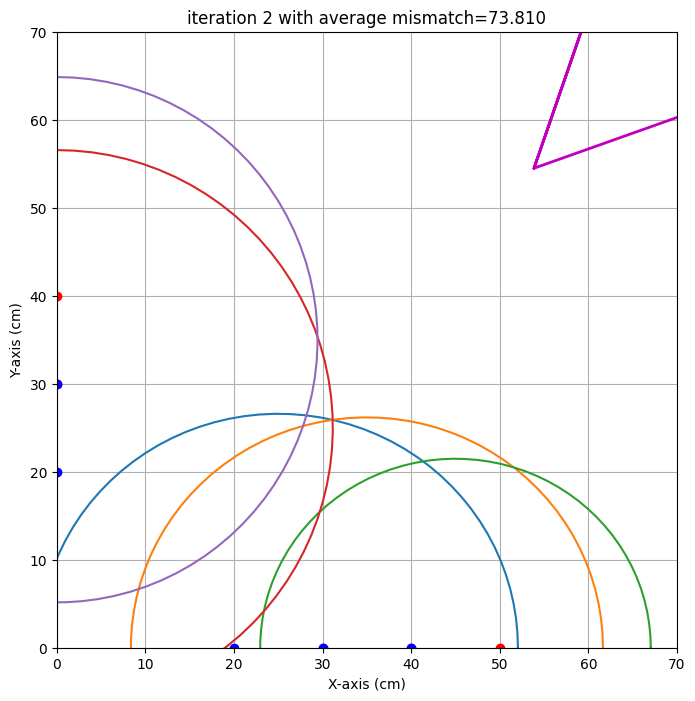

end iteration 2 with average mismatch=73.810


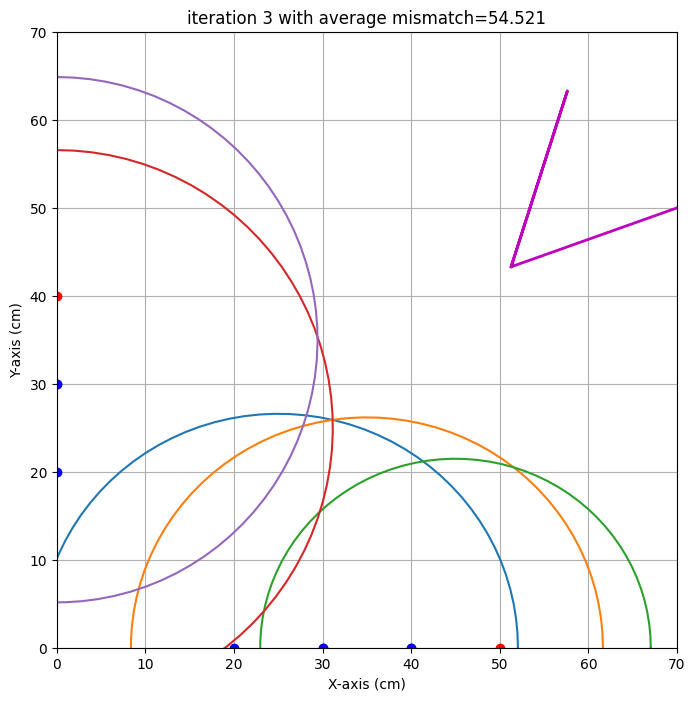

end iteration 3 with average mismatch=54.521


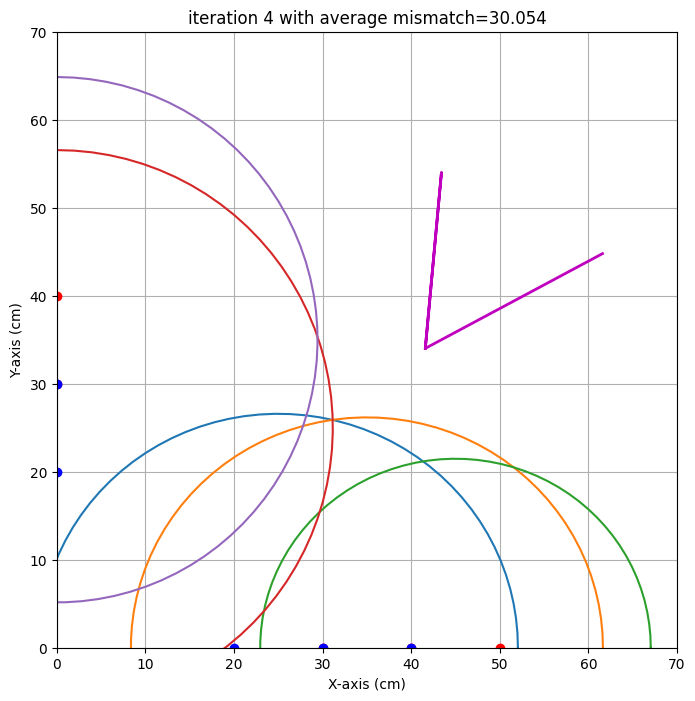

end iteration 4 with average mismatch=30.054


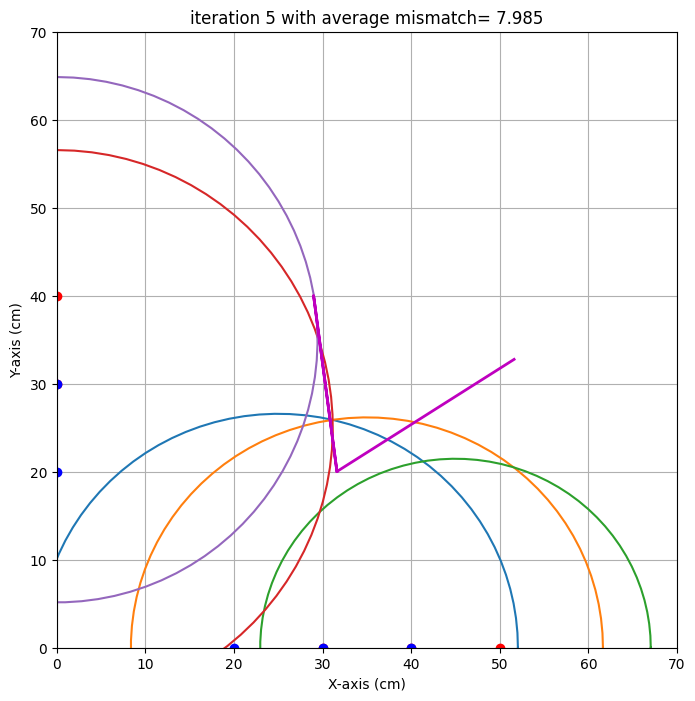

end iteration 5 with average mismatch= 7.985


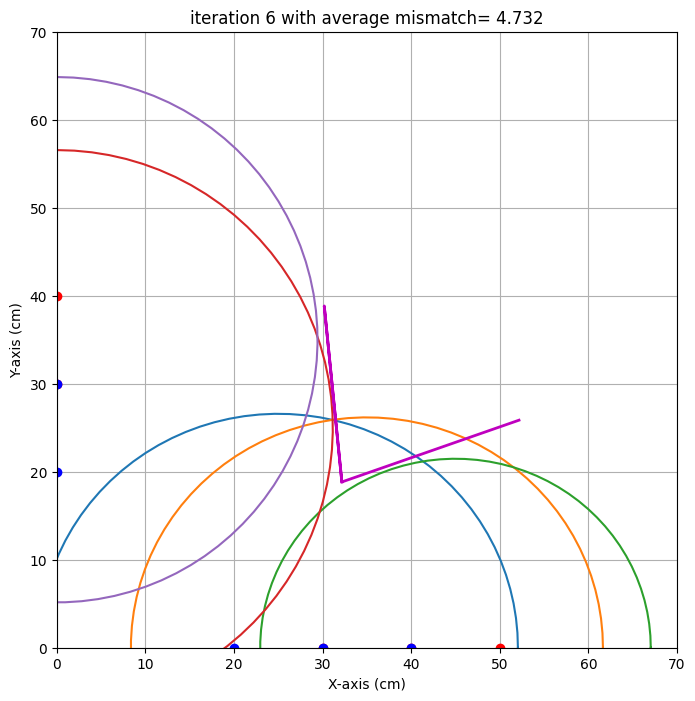

end iteration 6 with average mismatch= 4.732
end iteration 7 with average mismatch= 4.458


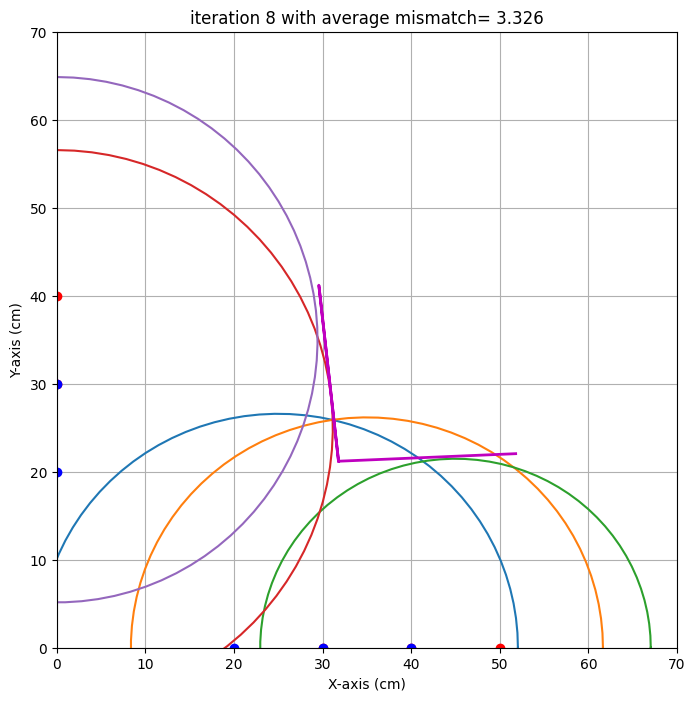

end iteration 8 with average mismatch= 3.326


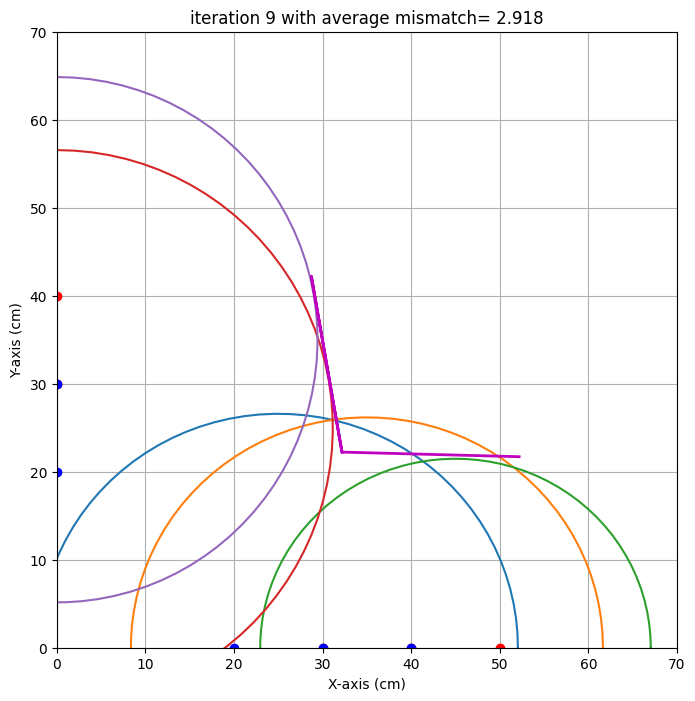

end iteration 9 with average mismatch= 2.918
end iteration 10 with average mismatch= 2.785


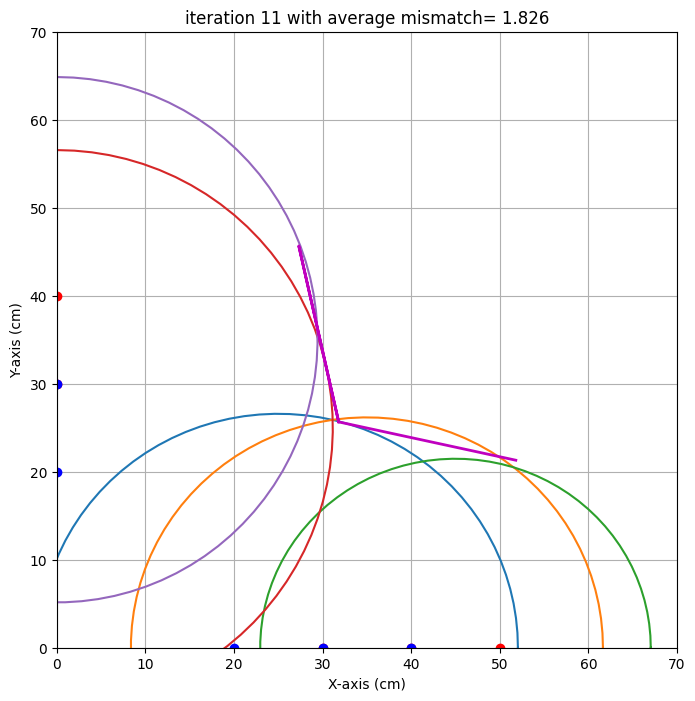

end iteration 11 with average mismatch= 1.826


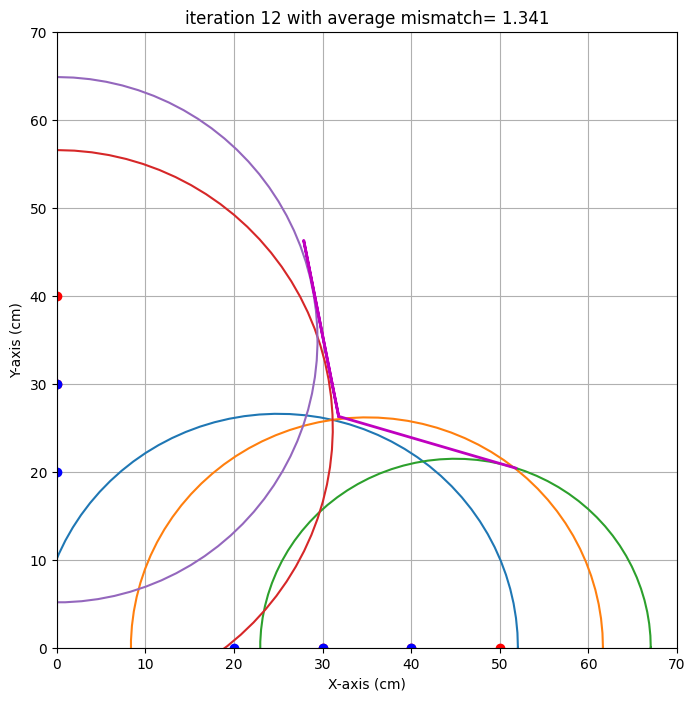

end iteration 12 with average mismatch= 1.341
end iteration 13 with average mismatch= 1.330
end iteration 14 with average mismatch= 1.329
end iteration 15 with average mismatch= 1.297
end iteration 16 with average mismatch= 1.260
end iteration 17 with average mismatch= 1.167
end iteration 18 with average mismatch= 1.155
end iteration 19 with average mismatch= 1.155
end iteration 20 with average mismatch= 1.155
end iteration 21 with average mismatch= 1.155
end iteration 22 with average mismatch= 1.155
end iteration 23 with average mismatch= 1.155
end iteration 24 with average mismatch= 1.155
end iteration 25 with average mismatch= 1.155
end iteration 26 with average mismatch= 1.155
end iteration 27 with average mismatch= 1.057
end iteration 28 with average mismatch= 1.057
end iteration 29 with average mismatch= 1.057
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration

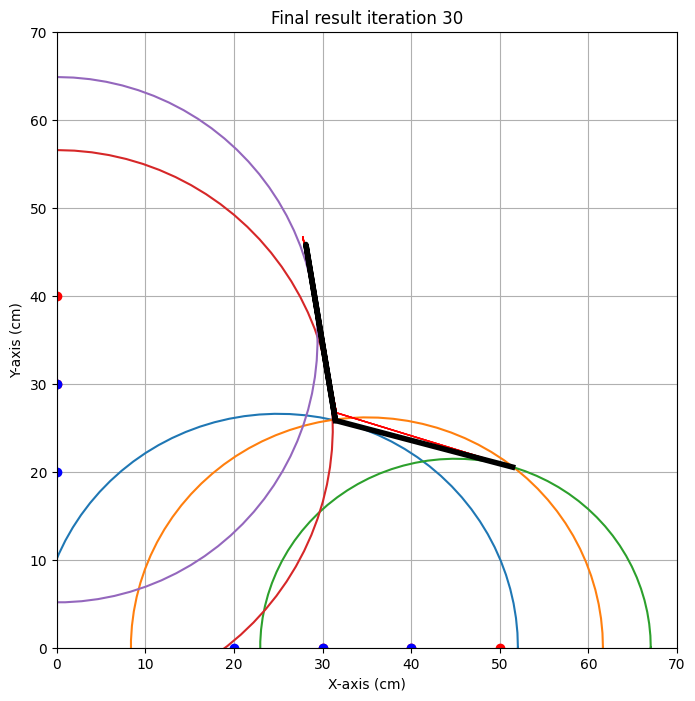

{'alpha': np.float64(-14.837956394310165), 'alpha_eps': np.float64(2.3469142492803634), 'beta': np.float64(-9.465329116019248), 'beta_eps': np.float64(1.2446198066448204), 'x0': np.float64(31.44503162180865), 'x0_eps': np.float64(0.10154146469611547), 'y0': np.float64(25.8246346860299), 'y0_eps': np.float64(0.8753089858498271)}
Steven
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  20  64.8
1   0  40   0  30  62.3
2   0  20   0  10  62.8
3  30   0  20   0  53.0
4  40   0  30   0  48.1


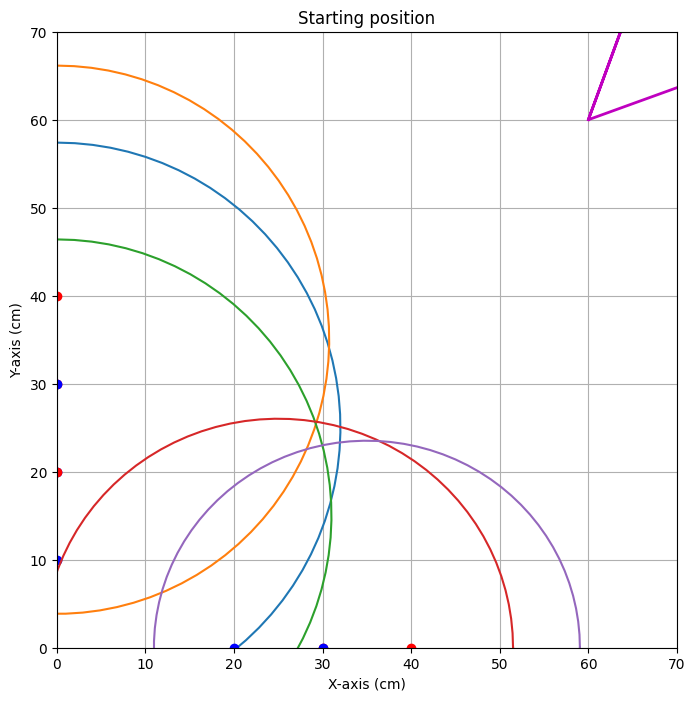


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=86.766


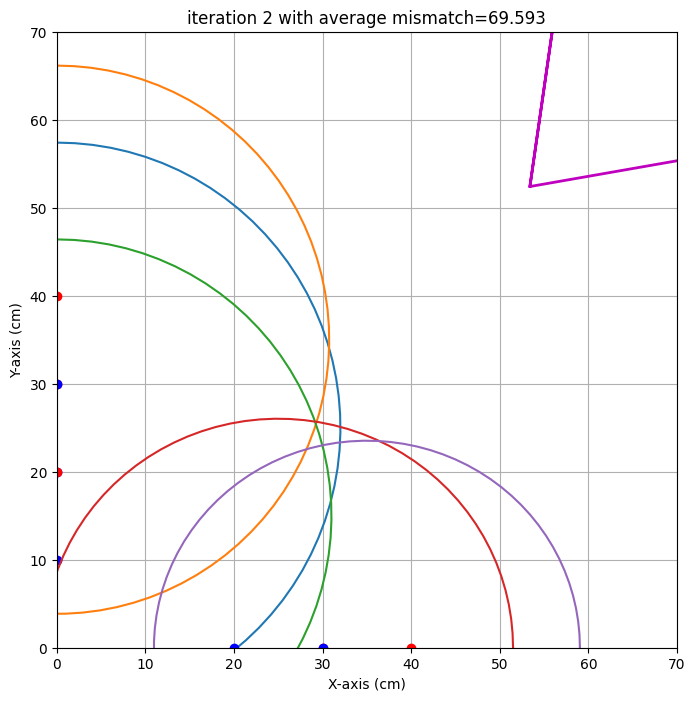

end iteration 2 with average mismatch=69.593


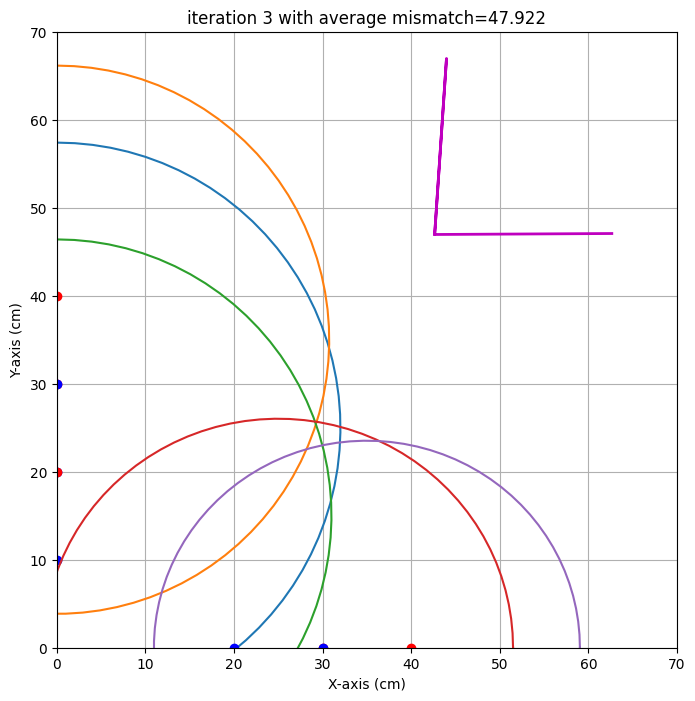

end iteration 3 with average mismatch=47.922


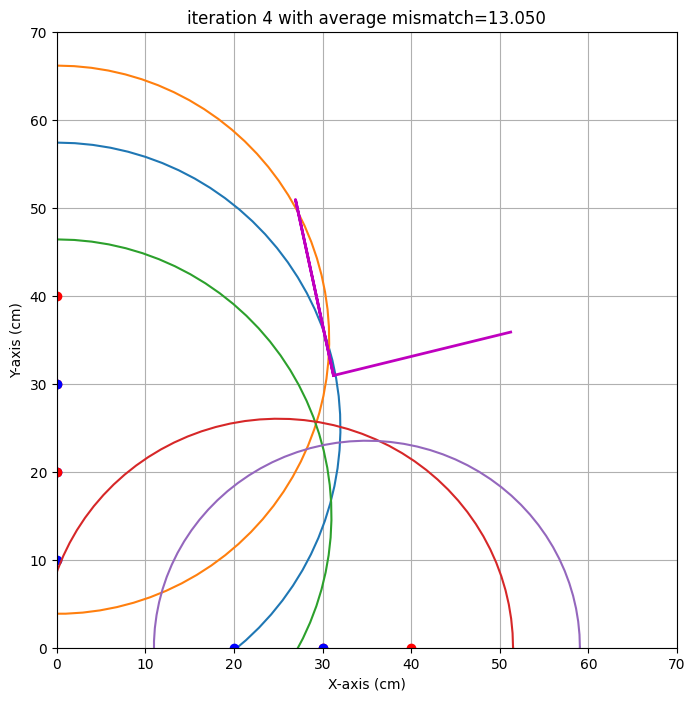

end iteration 4 with average mismatch=13.050


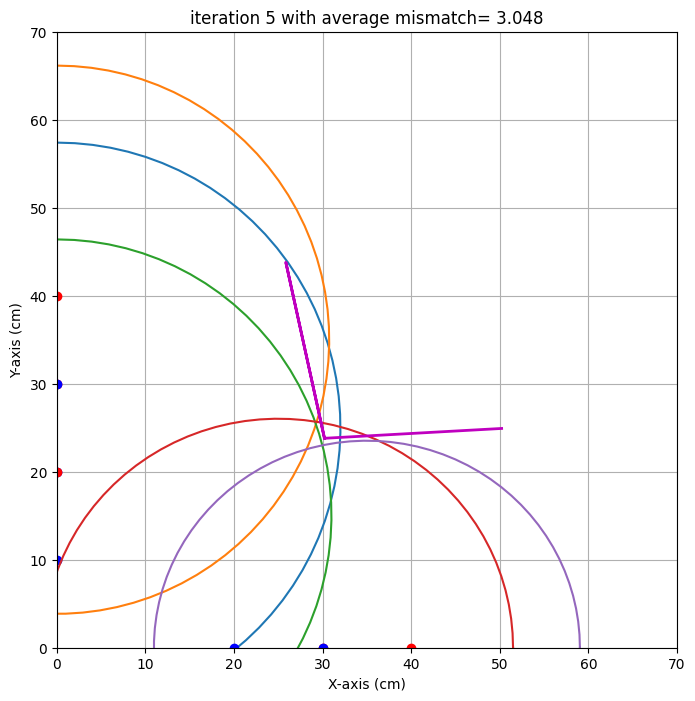

end iteration 5 with average mismatch= 3.048
end iteration 6 with average mismatch= 2.876
end iteration 7 with average mismatch= 2.873
end iteration 8 with average mismatch= 2.872
end iteration 9 with average mismatch= 2.847
end iteration 10 with average mismatch= 2.795
end iteration 11 with average mismatch= 2.639
end iteration 12 with average mismatch= 2.639
end iteration 13 with average mismatch= 2.639
end iteration 14 with average mismatch= 2.602


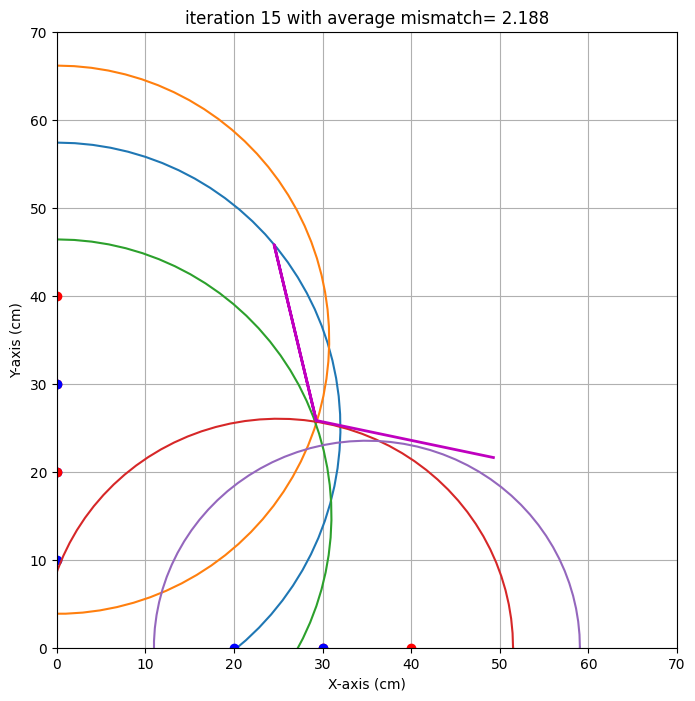

end iteration 15 with average mismatch= 2.188
end iteration 16 with average mismatch= 2.095
end iteration 17 with average mismatch= 2.090
end iteration 18 with average mismatch= 2.082
end iteration 19 with average mismatch= 2.068
end iteration 20 with average mismatch= 2.068
end iteration 21 with average mismatch= 2.068
end iteration 22 with average mismatch= 2.068
end iteration 23 with average mismatch= 2.068
end iteration 24 with average mismatch= 2.065
end iteration 25 with average mismatch= 2.065
end iteration 26 with average mismatch= 2.065
end iteration 27 with average mismatch= 2.065
end iteration 28 with average mismatch= 2.065
end iteration 29 with average mismatch= 2.064
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 2.063
###############################################################################
end of iteration  30
Best alpha= -14.70 with uncertainty=   3.41
Best beta 

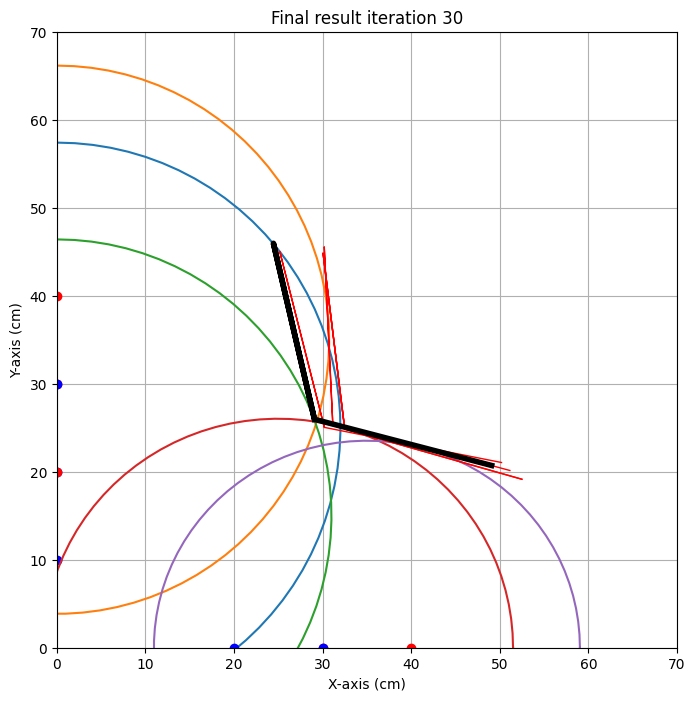

{'alpha': np.float64(-14.697588886441311), 'alpha_eps': np.float64(3.4056095178474095), 'beta': np.float64(-13.049098948175272), 'beta_eps': np.float64(10.306698441259705), 'x0': np.float64(29.079493738709186), 'x0_eps': np.float64(3.4182215665763174), 'y0': np.float64(25.95694915712198), 'y0_eps': np.float64(1.1073910575116948)}


In [16]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [17]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 33.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 23.5. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 14.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 10.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

Marjoksi 
x0 target is : 33.0. Gevonden waarde: 31.4 cm met een standaardafwijking van 0.1 cm 
y0 target is : 23.5. Gevonden waarde: 25.8 cm met een standaardafwijking van 0.9 cm 
alpha target is : 14.0. Gevonden waarde: -14.8 graden met een standaardafwijking van 2.3 graad 
beta target is : 10.0. Gevonden waarde: -9.5 graden met een standaardafwijking van 1.2 graad 

Steven 
x0 target is : 33.0. Gevonden waarde: 29.1 cm met een standaardafwijking van 3.4 cm 
y0 target is : 23.5. Gevonden waarde: 26.0 cm met een standaardafwijking van 1.1 cm 
alpha target is : 14.0. Gevonden waarde: -14.7 graden met een standaardafwijking van 3.4 g

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Eindalgoritme.png)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (3018683157.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")